In [1]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler

In [2]:
scaler_X = MinMaxScaler()
sensor_df = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
sensor_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm]
Time_[s],,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.817045,0.293651,0.436154,0.397692,0.107143,0.985937,0.757580,0.59375,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.999849
0.05,2,0.135068,0.817045,0.285714,0.436154,0.397822,0.107143,0.985937,0.750271,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999842
0.10,2,0.135068,0.817045,0.293651,0.436154,0.398065,0.107143,0.984375,0.698300,0.59375,0.999967,1.000000,0.456468,0.570124,0.000004,0.900879,0.000373,0.999540
0.15,2,0.136307,0.817045,0.293651,0.436154,0.397887,0.107143,0.985937,0.585460,0.62500,0.999967,1.000000,0.456468,0.570124,0.000005,0.900879,0.000373,0.998401
0.20,2,0.135068,0.817045,0.285714,0.436154,0.397741,0.107143,0.984375,0.476972,0.65625,0.999967,1.000000,0.456468,0.570124,0.000002,0.900879,0.000373,0.997003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.875032,0.285714,0.419720,0.414831,0.785714,0.926562,0.793701,0.43750,0.000007,0.997979,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.35,314,0.074349,0.872084,0.293651,0.419720,0.415124,0.785714,0.928125,0.793552,0.43750,0.000007,0.998670,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849
86.40,314,0.074349,0.874473,0.285714,0.419720,0.415188,0.785714,0.926562,0.793404,0.43750,0.000007,0.999223,0.456468,0.000004,0.984199,0.094463,0.000373,0.999849


In [3]:
# import numpy as np

# # Keep features with variance above a threshold
# variance_threshold = 0.09
# sensor_df = sensor_df.loc[:, sensor_df.var() > variance_threshold]

In [4]:
groups = []
max_len = sensor_df.groupby("Experiment_ID").size().max()  # longest experiment
num_features = sensor_df.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in sensor_df.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
time_series_data = np.nan_to_num(X, nan=0.0)[:,:,:]

In [5]:
import pandas as pd
import json
# Load JSON intervals
with open("../data/machine-and-movement.json", "r") as f:
    intervals_data = json.load(f)
# Make sure index is float (seconds)
sensor_df.index = sensor_df.index.astype(float)

sensor_df["Experiment_ID"] = sensor_df["Experiment_ID"].astype(str)

# Create a list to store labels for each timestamp
labels = []

# Iterate over sensor timestamps
for timestamp, row in sensor_df.iterrows():
    exp_id = row["Experiment_ID"]
    assigned_label = "No Label"
    
    # Check if this experiment has labeled intervals
    if exp_id in intervals_data:
        for interval in intervals_data[exp_id]:
            start = float(interval["start"])
            end = float(interval["end"])
            if start <= float(timestamp) <= end:
                assigned_label = interval.get("label", "No Label")
                break  # stop at the first match
    
    labels.append(assigned_label)

# Add labels to the DataFrame
sensor_df["Label"] = labels

In [6]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Make sure we are not working on a view
sensor_df = sensor_df.copy()

# Select features (drop Experiment_ID and Label)
feature_cols = [col for col in sensor_df.columns if col not in ['Experiment_ID', 'Label']]

# Normalize features
scaler = MinMaxScaler()
sensor_df.loc[:, feature_cols] = scaler.fit_transform(sensor_df[feature_cols])

# Encode labels
le = LabelEncoder()
sensor_df.loc[:, 'Label_encoded'] = le.fit_transform(sensor_df['Label'])
sensor_df


,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm],Label,Label_encoded
Time_[s],,,,,,,,,,,,,,,,,,,,
0.00,2,0.135068,0.836854,0.293651,0.436154,0.462295,0.107143,0.985460,0.764309,0.59375,0.999970,1.000000,0.538386,0.570124,0.000005,0.900879,0.000357,0.999856,No Label,3.0
0.05,2,0.135068,0.836854,0.285714,0.436154,0.462446,0.107143,0.985460,0.756936,0.59375,0.999970,1.000000,0.538386,0.570124,0.000004,0.900879,0.000357,0.999849,No Label,3.0
0.10,2,0.135068,0.836854,0.293651,0.436154,0.462729,0.107143,0.983845,0.704503,0.59375,0.999970,1.000000,0.538386,0.570124,0.000004,0.900879,0.000357,0.999547,No Label,3.0
0.15,2,0.136307,0.836854,0.293651,0.436154,0.462521,0.107143,0.985460,0.590661,0.62500,0.999970,1.000000,0.538386,0.570124,0.000005,0.900879,0.000357,0.998408,No Label,3.0
0.20,2,0.135068,0.836854,0.285714,0.436154,0.462351,0.107143,0.983845,0.481209,0.65625,0.999970,1.000000,0.538386,0.570124,0.000002,0.900879,0.000357,0.997010,No Label,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.30,314,0.074349,0.905141,0.285714,0.419720,0.482218,0.785714,0.924071,0.800751,0.43750,0.000004,0.997979,0.538386,0.000004,0.984200,0.094463,0.000357,0.999856,No Label,3.0
86.35,314,0.074349,0.901670,0.293651,0.419720,0.482558,0.785714,0.925687,0.800601,0.43750,0.000004,0.998670,0.538386,0.000004,0.984200,0.094463,0.000357,0.999856,No Label,3.0
86.40,314,0.074349,0.904483,0.285714,0.419720,0.482633,0.785714,0.924071,0.800452,0.43750,0.000004,0.999223,0.538386,0.000004,0.984200,0.094463,0.000357,0.999856,No Label,3.0


In [7]:
import numpy as np
import pandas as pd

# Make sure we are working with a copy
sensor_df = sensor_df.copy()

# Get all unique experiments
experiments = sensor_df["Experiment_ID"].unique()
np.random.seed(42)  # for reproducibility
np.random.shuffle(experiments)

# Compute sizes
n_total = len(experiments)
n_test = int(0.1 * n_total)
n_val = int(0.2 * n_total)

test_exps = experiments[:n_test]
val_exps = experiments[n_test:n_test + n_val]
train_exps = experiments[n_test + n_val:]

# Create splits
train_df = sensor_df[sensor_df["Experiment_ID"].isin(train_exps)].copy()
val_df   = sensor_df[sensor_df["Experiment_ID"].isin(val_exps)].copy()
test_df  = sensor_df[sensor_df["Experiment_ID"].isin(test_exps)].copy()

print(f"Total experiments: {n_total}")
print(f"Train experiments: {len(train_exps)}")
print(f"Val experiments: {len(val_exps)}")
print(f"Test experiments: {len(test_exps)}")


Total experiments: 100
Train experiments: 70
Val experiments: 20
Test experiments: 10


In [8]:
# List of experiment IDs in the test set
print("Test set experiments:", test_exps.tolist(), val_exps.tolist())

Test set experiments: ['262', '85', '223', '77', '75', '70', '42', '253', '22', '2'] ['38', '61', '232', '64', '285', '10', '241', '244', '26', '62', '87', '277', '57', '73', '220', '32', '71', '305', '20', '229']


In [9]:
val_df

,Experiment_ID,MACHINE_BEND-DIE_LATERAL_Max_Torque_[%],MACHINE_BEND-DIE_ROTATING_Max_Torque_[%],MACHINE_BEND-DIE_VERTICAL_Max_Torque_[%],MACHINE_CLAMP-DIE_LATERAL_Max_Torque_[%],MACHINE_COLLET_AXIAL_Max_Torque_[%],MACHINE_COLLET_ROTATING_Max_Torque_[%],MACHINE_MANDREL_AXIAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LATERAL_Max_Torque_[%],MACHINE_PRESSURE-DIE_LEFT_AXIAL_Max_Torque_[%],BEND-DIE_LATERAL_Movement_[mm],BEND-DIE_ROTATING_Angle_[°],BEND-DIE_VERTICAL_Movement_[mm],CLAMP-DIE_LATERAL_Movement_[mm],COLLET_AXIAL_Movement_[mm],MANDREL_AXIAL_Movement_[mm],PRESSURE-DIE_AXIAL_Movement_[mm],PRESSURE-DIE_LATERAL_Movement_[mm],Label,Label_encoded
Time_[s],,,,,,,,,,,,,,,,,,,,
0.00,10,0.135068,0.836854,0.277778,0.436532,0.462502,0.178571,0.985460,0.756993,0.59375,0.999970,1.000000,0.538386,0.570124,0.000002,0.918900,0.000357,0.999856,No Label,3.0
0.05,10,0.135068,0.836854,0.277778,0.436532,0.462615,0.178571,0.983845,0.755311,0.56250,0.999970,1.000000,0.538386,0.570124,0.000005,0.918900,0.000357,0.999856,No Label,3.0
0.10,10,0.135068,0.836735,0.277778,0.436532,0.462446,0.178571,0.985460,0.726577,0.59375,0.999970,1.000000,0.563814,0.570124,0.000004,0.918900,0.000357,0.999744,No Label,3.0
0.15,10,0.135068,0.836735,0.277778,0.436532,0.462125,0.142857,0.985460,0.634142,0.56250,0.999970,1.000000,0.538386,0.570124,0.000004,0.918900,0.000357,0.999005,No Label,3.0
0.20,10,0.135068,0.836854,0.277778,0.436532,0.462012,0.178571,0.985460,0.519586,0.56250,0.999970,1.000000,0.538386,0.570124,0.000004,0.918900,0.000357,0.997417,No Label,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86.25,305,0.074349,0.904961,0.293651,0.419720,0.482124,0.785714,0.936995,0.797445,0.40625,0.000004,0.997823,0.538386,0.000004,0.984200,0.060675,0.000357,0.999856,No Label,3.0
86.30,305,0.074349,0.900293,0.293651,0.419720,0.482162,0.785714,0.936995,0.797468,0.40625,0.000004,0.998543,0.538386,0.000004,0.984200,0.060675,0.000357,0.999856,No Label,3.0
86.35,305,0.075589,0.902149,0.293651,0.419720,0.482218,0.785714,0.936995,0.797180,0.43750,0.000004,0.999126,0.538386,0.000004,0.984199,0.060675,0.000357,0.999856,No Label,3.0


In [10]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset

# Make sure features are numeric
sensor_df[feature_cols] = sensor_df[feature_cols].apply(pd.to_numeric, errors='coerce')
# Fill any NaNs with 0 (or another strategy)
sensor_df[feature_cols] = sensor_df[feature_cols].fillna(0.0)

# Dataset class
class SegmentDatasetAllTimestamps(Dataset):
    def __init__(self, sensor_df, feature_cols):
        self.segments = []
        self.labels = []

        # Collect unique labels
        self.unique_labels = sorted(sensor_df["Label"].unique())
        self.label_to_idx = {l: i for i, l in enumerate(self.unique_labels)}

        for _, row in sensor_df.iterrows():
            feature_vector = row[feature_cols].values.astype(np.float32)  # ensure float32
            self.segments.append(torch.tensor(feature_vector, dtype=torch.float32))
            self.labels.append(self.label_to_idx[row["Label"]])

        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.segments)

    def __getitem__(self, idx):
        return self.segments[idx], self.labels[idx]

# Create dataset
train_dataset = SegmentDatasetAllTimestamps(train_df, feature_cols)
val_dataset = SegmentDatasetAllTimestamps(val_df, feature_cols)
test_dataset = SegmentDatasetAllTimestamps(test_df,feature_cols)

In [11]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super(LSTMClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
# Ensure Experiment_ID is string (since JSON keys are strings like '2', '4', '6', ...)
        # Fully connected layer to map LSTM output to class logits
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        # LSTM forward
        out, _ = self.lstm(x, (h0, c0))  # out shape: (batch_size, seq_len, hidden_size)

        # We want a classification for each timestamp (seq_len)
        out = self.fc(out)  # out shape: (batch_size, seq_len, num_classes)
        return out


In [12]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np

# --- Hyperparameters ---
input_size = len(feature_cols)
hidden_size = 64
num_layers = 2
num_classes = len(train_dataset.unique_labels)
batch_size = 64
num_epochs = 100
learning_rate = 1e-3
patience = 10  # early stopping patience

# --- DataLoaders ---
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# --- Model, loss, optimizer ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMClassifier(input_size, hidden_size, num_layers, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# --- Training loop with early stopping ---
best_val_loss = np.inf
counter = 0

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.unsqueeze(1).to(device)  # (batch_size, seq_len=1, input_size)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)  # (batch_size, seq_len, num_classes)
        outputs = outputs.squeeze(1)  # remove seq_len dim
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            X_val = X_val.unsqueeze(1).to(device)
            y_val = y_val.to(device)
            outputs = model(X_val).squeeze(1)
            loss = criterion(outputs, y_val)
            val_loss += loss.item() * X_val.size(0)
    val_loss /= len(val_loader.dataset)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_lstm_model.pth")  # save best model
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# --- Load best model ---
model.load_state_dict(torch.load("best_lstm_model.pth"))
print("Training complete. Best model loaded.")


Epoch 1: Train Loss = 0.1742, Val Loss = 0.0600
Epoch 2: Train Loss = 0.0674, Val Loss = 0.0480
Epoch 3: Train Loss = 0.0589, Val Loss = 0.0454
Epoch 4: Train Loss = 0.0555, Val Loss = 0.0497
Epoch 5: Train Loss = 0.0529, Val Loss = 0.0395
Epoch 6: Train Loss = 0.0511, Val Loss = 0.0435
Epoch 7: Train Loss = 0.0509, Val Loss = 0.0422
Epoch 8: Train Loss = 0.0483, Val Loss = 0.0381
Epoch 9: Train Loss = 0.0484, Val Loss = 0.0431
Epoch 10: Train Loss = 0.0474, Val Loss = 0.0422
Epoch 11: Train Loss = 0.0468, Val Loss = 0.0434
Epoch 12: Train Loss = 0.0455, Val Loss = 0.0408
Epoch 13: Train Loss = 0.0453, Val Loss = 0.0385
Epoch 14: Train Loss = 0.0447, Val Loss = 0.0396
Epoch 15: Train Loss = 0.0446, Val Loss = 0.0404
Epoch 16: Train Loss = 0.0443, Val Loss = 0.0428
Epoch 17: Train Loss = 0.0432, Val Loss = 0.0391
Epoch 18: Train Loss = 0.0430, Val Loss = 0.0466
Early stopping triggered!
Training complete. Best model loaded.


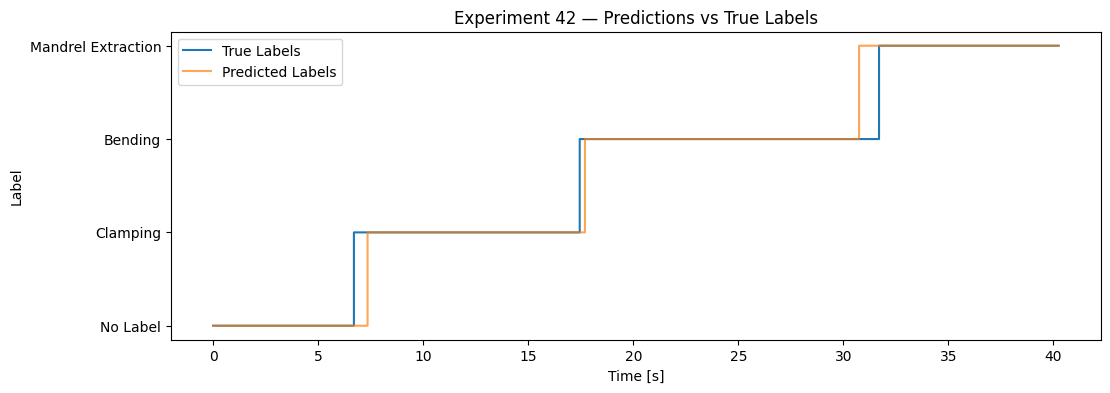

In [31]:
import torch
import matplotlib.pyplot as plt
import random

def plot_predictions_vs_true(model, dataset, sensor_df, feature_cols, device="cpu"):
    model.eval()
    
    # Pick one random experiment
    exp_id = random.choice(test_exps.tolist())
    exp_data = sensor_df[sensor_df["Experiment_ID"] == exp_id]
    
    # Features only
    X = torch.tensor(exp_data[feature_cols].values, dtype=torch.float32).to(device)
    X = X.unsqueeze(0)  # [1, seq_len, num_features]
    
    # True labels (encoded already in dataset.label_to_idx)
    y_true = exp_data["Label"].values
    
    # Run model
    with torch.no_grad():
        outputs = model(X)  # [1, seq_len, num_classes]
        y_pred = torch.argmax(outputs, dim=-1).squeeze(0).cpu().numpy()
    
    # Map back to label names
    idx_to_label = {v: k for k, v in dataset.label_to_idx.items()}
    y_true_names = [label if isinstance(label, str) else idx_to_label[label] for label in y_true]
    y_pred_names = [idx_to_label[p] for p in y_pred]
    
    # Plot
    timestamps = exp_data.index.astype(float)
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(timestamps, y_true_names, label="True Labels", drawstyle="steps-post")
    ax.plot(timestamps, y_pred_names, label="Predicted Labels", drawstyle="steps-post", alpha=0.7)
    
    ax.set_title(f"Experiment {exp_id} — Predictions vs True Labels")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Label")
    ax.legend()
    plt.show()

# Example usage:
plot_predictions_vs_true(model, test_dataset, sensor_df, feature_cols)
